<a href="https://colab.research.google.com/github/96rodrigues/IP---Python/blob/main/krigragem_IP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install pykrige

In [1]:
!pip install pykrige rasterio geopandas
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from pykrige.ok import OrdinaryKriging
import rasterio
from rasterio.transform import from_origin
from rasterio.mask import mask

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 16.1 MB/s eta 0:00:00


In [ ]:
ponto_pluvio=gpd.read_file("/content/Dados da krikagem/chuva.shp")

ponto_pluvio.head()

municipio=gpd.read_file("/content/Dados da krikagem/quixeramobim.shp")



In [ ]:
saida_tif="IP.tif"

In [ ]:
ponto_pluvio=gpd.read_file("/content/Dados da krikagem/chuva.shp")
municipio=gpd.read_file("/content/Dados da krikagem/quixeramobim.shp")
VARIOGRAM_MODEL="spherical"


In [ ]:
if ponto_pluvio.crs is None:
    print(f"AVISO: shapefile de pontos sem CRS definido. Assumindo {31984}.")
    ponto_pluvio = ponto_pluvio.set_crs(31984)
else:
    pontos = ponto_pluvio.to_crs(31984)

if municipio.crs is None:
    print(f"AVISO: shapefile do município sem CRS definido. Assumindo {31984}.")
    municipio = municipio.set_crs(31984)
else:
    municipio = municipio.to_crs(31984)

In [ ]:
x=ponto_pluvio.geometry.x.values
y=ponto_pluvio.geometry.y.values
z=ponto_pluvio['IP_Crpn'].values

In [ ]:
print(f"Número de pontos pluviométricos: {len(z)}")

Número de pontos pluviométricos: 19


In [ ]:
xmin,ymin,xmax,ymax=municipio.total_bounds

grid_x=np.arange(xmin,xmax,350)
grid_y=np.arange(ymin,ymax,350)

In [ ]:
ok=OrdinaryKriging(
    x,y,z,
    variogram_model=VARIOGRAM_MODEL,
    verbose=False,
    enable_plotting= False
)
z_interp, variancia=ok.execute("grid",grid_x,grid_y)


In [ ]:
from rasterio.transform import from_origin
transform= from_origin(xmin,ymax,350,350)


In [ ]:
z_interp_raster = np.flipud(z_interp).astype("float32")


NODATA_VALOR = -9999.0

with rasterio.open(
    saida_tif,"w",
    driver="GTiff",
    height=z_interp_raster.shape[0],
    width=z_interp_raster.shape[1],
    count=1,
    dtype="float32",
    crs=ponto_pluvio.crs,
    transform=transform,
    notada=NODATA_VALOR,
)as dst:
  dst.write(z_interp_raster,1)



In [ ]:
with rasterio.open(saida_tif) as src:
    geometria_municipio = municipio.geometry.values
    imagem_recortada, transform_recortado = mask(
        src, geometria_municipio, crop=True, nodata=NODATA_VALOR
    )
    perfil = src.profile

perfil.update({
     "height": imagem_recortada.shape[1],
    "width": imagem_recortada.shape[2],
    "transform": transform_recortado,
    "nodata": NODATA_VALOR,

})


with rasterio.open(saida_tif, "w", **perfil) as dst:
    dst.write(imagem_recortada)

print(f"Raster salvo em: {saida_tif}")


Raster salvo em: IP.tif


Mapa salvo em: IP.tif


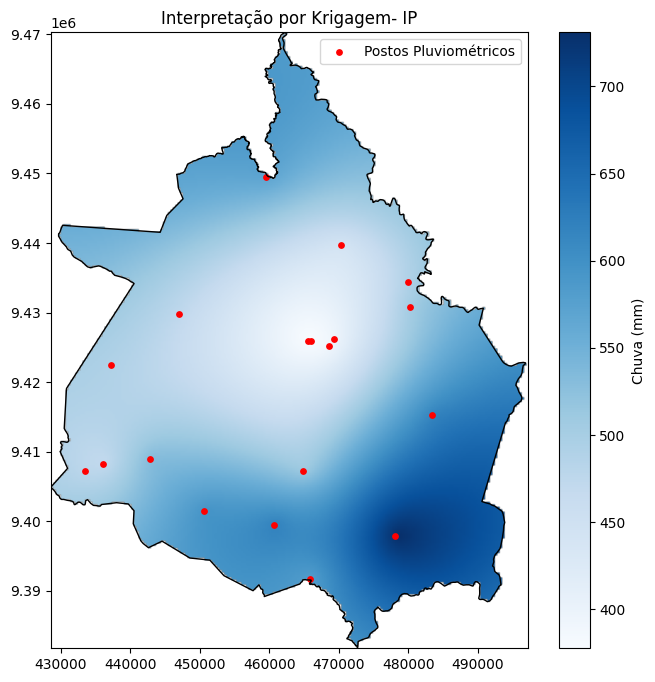

In [ ]:
from matplotlib.axes import Axes
from matplotlib.figure import Figure
ax: Axes
fig, ax = plt.subplots(figsize=(8,8))
imagem_plot=np.ma.masked_equal(imagem_recortada[0],NODATA_VALOR)
extent =[
  transform_recortado.c,
  transform_recortado.c + transform_recortado.a * imagem_recortada.shape[2],
  transform_recortado.f + transform_recortado.e * imagem_recortada.shape[1],
  transform_recortado.f,
  ]
im = ax.imshow(imagem_plot, extent= extent, cmap="Blues")
municipio.boundary.plot(ax=ax, color ="Black",linewidth=1)
ponto_pluvio.plot(ax=ax, color= "red", markersize=15, label="Postos Pluviométricos")

plt.colorbar(im, ax=ax, label= "Chuva (mm)")
ax.set_title("Interpretação por Krigagem- IP")
ax.legend()

plt.savefig(saida_tif,dpi=400, bbox_inches = "tight")

print(f"Mapa salvo em: {saida_tif}")
